In [2]:
import pandas as pd

# Read two data sets 
restaurants_df = pd.read_csv('Dataset/SemEval2015/Laptops.csv')
laptops_df = pd.read_csv('Dataset/SemEval2015/Restaurants.csv')

# Keep only the columns we care about
restaurants_df = restaurants_df[['text', 'category', 'polarity']]
laptops_df = laptops_df[['text', 'category', 'polarity']]

# Remove missing values
restaurants_df.dropna(subset=['text', 'category', 'polarity'], inplace=True)
laptops_df.dropna(subset=['text', 'category', 'polarity'], inplace=True)
# View basic data
print(restaurants_df.sample(5))
print(laptops_df.sample(5))

                                                   text  \
6449  I just hope the reputation that Toshiba has is...   
3184  The 2 GB of RAM is plenty, able to run Windows...   
213   I can guarantee this will be the last Dell I w...   
8714        i would have to say that overall its great!   
482   The rep did not even answer my question, I had...   

                          category  polarity  
6449               COMPANY#GENERAL   neutral  
3184  LAPTOP#OPERATION_PERFORMANCE  positive  
213                 LAPTOP#GENERAL  negative  
8714                LAPTOP#GENERAL  positive  
482                SUPPORT#QUALITY  negative  
                                                   text              category  \
6003  Ess-A-Bagel (either by Sty-town or midtown) is...          FOOD#QUALITY   
7829  The food is delicious - from the specials to t...          FOOD#QUALITY   
2559          And where does Patis go wrong; no where.     RESTAURANT#GENERAL   
9999  The have over 100 different beers

In [4]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Custom tokenizer function
def custom_tokenizer(text):
    tokens = word_tokenize(text.lower()) 
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

# Create a TF-IDF vectorizer using a custom tokenizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    tokenizer=custom_tokenizer,
    stop_words='english',
    lowercase=False  
)

# Fit and transform
X_tfidf_restaurants = tfidf_vectorizer.fit_transform(restaurants_df['text'])
X_tfidf_laptops = tfidf_vectorizer.fit_transform(laptops_df['text'])
print(f"TF-IDF feature dimension：{X_tfidf_restaurants.shape}")
print(f"TF-IDF feature dimension：{X_tfidf_laptops.shape}")

[nltk_data] Downloading package punkt to /Users/jjp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/jjp/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/jjp/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'le', 'u', 'wa'] not in stop_words.
  warnings.warn(


TF-IDF feature dimension：(10000, 1998)
TF-IDF feature dimension：(10000, 1642)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Label encoding (polarity)
y_polarity_restaurants = restaurants_df['polarity']

# Divide the training set and test set
X_train_restaurants, X_test_restaurants, y_train_restaurants, y_test_restaurants = train_test_split(
    X_tfidf_restaurants, y_polarity_restaurants, test_size=0.2, random_state=42, stratify=y_polarity_restaurants
)

# Create and train an SVM model
svm_polarity_restaurants = LinearSVC()
svm_polarity_restaurants.fit(X_train_restaurants, y_train_restaurants)

# Predict and Evaluation
y_pred_restaurants = svm_polarity_restaurants.predict(X_test_restaurants)

print(" Sentiment classification (polarity) evaluation results for restaurants: ")
print(classification_report(y_test_restaurants, y_pred_restaurants))

 Sentiment classification (polarity) evaluation results for restaurants: 
              precision    recall  f1-score   support

    negative       0.95      0.95      0.95       777
     neutral       0.72      0.52      0.61       101
    positive       0.94      0.96      0.95      1122

    accuracy                           0.94      2000
   macro avg       0.87      0.81      0.84      2000
weighted avg       0.93      0.94      0.93      2000



/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [8]:
# Label encoding (polarity)
y_polarity_laptops = laptops_df['polarity']

# Divide the training set and test set
X_train_laptops, X_test_laptops, y_train_laptops, y_test_laptops = train_test_split(
    X_tfidf_laptops, y_polarity_laptops, test_size=0.2, random_state=42, stratify=y_polarity_laptops
)

# Create and train an SVM model
svm_polarity_laptops = LinearSVC()
svm_polarity_laptops.fit(X_train_laptops, y_train_laptops)

# Predict and Evaluation
y_pred_laptops = svm_polarity_laptops.predict(X_test_laptops)

print("Sentiment classification (polarity) evaluation results for laptops:")
print(classification_report(y_test_laptops, y_pred_laptops))

Sentiment classification (polarity) evaluation results for laptops:
              precision    recall  f1-score   support

    negative       0.90      0.91      0.90       443
     neutral       0.80      0.84      0.82        58
    positive       0.97      0.96      0.97      1499

    accuracy                           0.95      2000
   macro avg       0.89      0.91      0.90      2000
weighted avg       0.95      0.95      0.95      2000



/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Split the train and text data
X_train_restaurants, X_test_restaurants, y_train_restaurants, y_test_restaurants = train_test_split(
    X_tfidf_restaurants, y_polarity_restaurants, test_size=0.2, random_state=42, stratify=y_polarity_restaurants
)

# Build and train the Decision tree
dt_restaurants = DecisionTreeClassifier(random_state=42)
dt_restaurants.fit(X_train_restaurants, y_train_restaurants)

# Predict and Evaluation
y_pred_dt_restaurants = dt_restaurants.predict(X_test_restaurants)

print("Decision Tree evaluation results for restaurants:")
print(classification_report(y_test_restaurants, y_pred_dt_restaurants))


Decision Tree evaluation results for restaurants:
              precision    recall  f1-score   support

    negative       0.95      0.97      0.96       777
     neutral       0.71      0.70      0.71       101
    positive       0.97      0.96      0.96      1122

    accuracy                           0.95      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.95      0.95      0.95      2000



In [12]:
# Split the trian and Test data
X_train_laptops, X_test_laptops, y_train_laptops, y_test_laptops = train_test_split(
    X_tfidf_laptops, y_polarity_laptops, test_size=0.2, random_state=42, stratify=y_polarity_laptops
)

# Bulid the Decision Tree Model
dt_laptops = DecisionTreeClassifier(random_state=42)
dt_laptops.fit(X_train_laptops, y_train_laptops)

# Predict and Evaluation
y_pred_dt_laptops = dt_laptops.predict(X_test_laptops)

print("Decision Tree evaluation results for laptops:")
print(classification_report(y_test_laptops, y_pred_dt_laptops))


Decision Tree evaluation results for laptops:
              precision    recall  f1-score   support

    negative       0.89      0.92      0.90       443
     neutral       0.81      0.88      0.84        58
    positive       0.97      0.96      0.97      1499

    accuracy                           0.95      2000
   macro avg       0.89      0.92      0.90      2000
weighted avg       0.95      0.95      0.95      2000



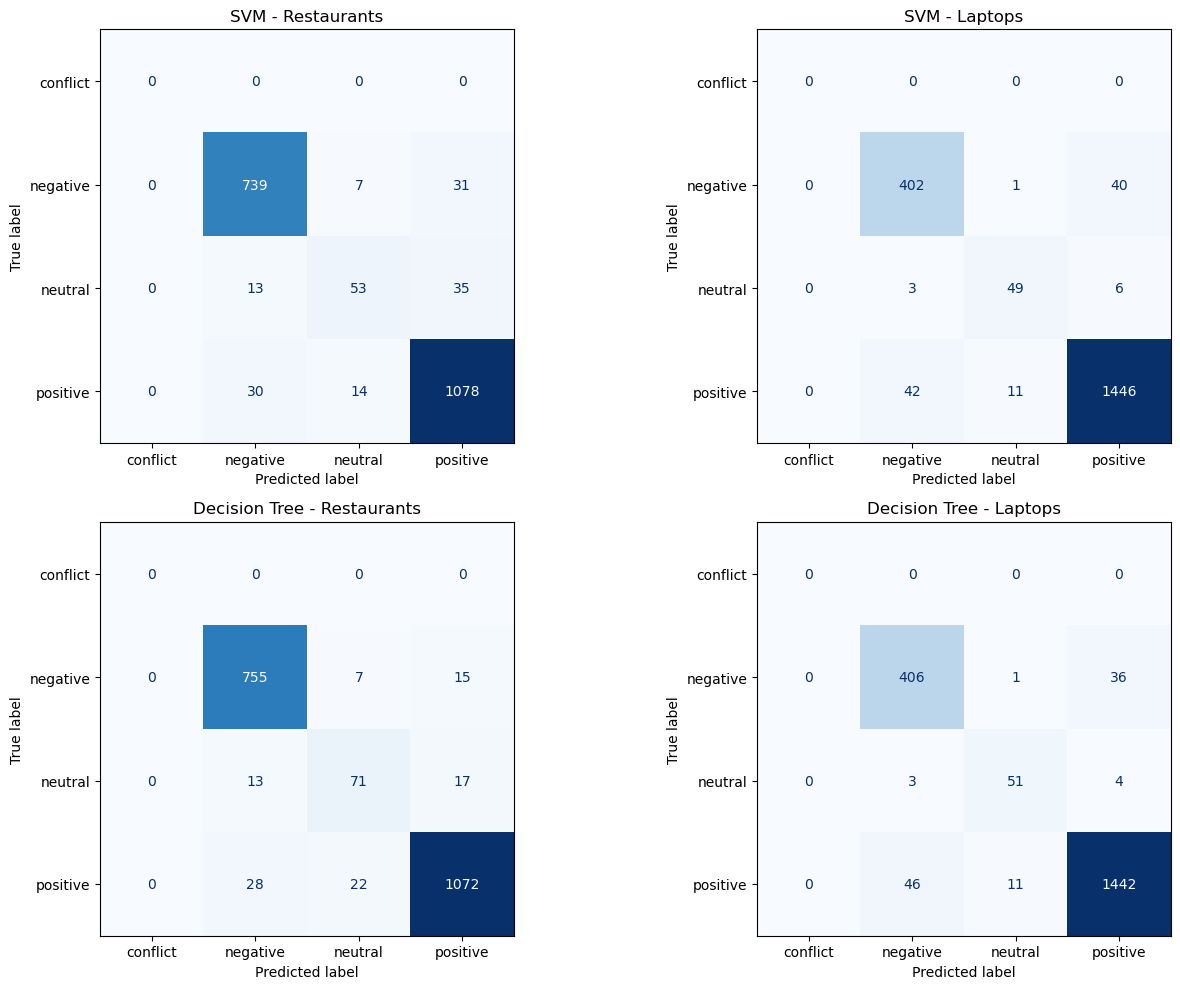

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define the class labels used in your polarity classification
class_labels = ['conflict', 'negative', 'neutral', 'positive']
cm1 = confusion_matrix(y_test_restaurants, y_pred_restaurants, labels=class_labels)
cm2 = confusion_matrix(y_test_laptops, y_pred_laptops, labels=class_labels)
cm3 = confusion_matrix(y_test_restaurants, y_pred_dt_restaurants, labels=class_labels)
cm4 = confusion_matrix(y_test_laptops, y_pred_dt_laptops, labels=class_labels)

# Create subplots to show all four confusion matrices
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# SVM - Restaurants
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_labels)
disp1.plot(ax=axs[0, 0], cmap='Blues', colorbar=False)
axs[0, 0].set_title("SVM - Restaurants")

# SVM - Laptops
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=class_labels)
disp2.plot(ax=axs[0, 1], cmap='Blues', colorbar=False)
axs[0, 1].set_title("SVM - Laptops")

# Decision Tree - Restaurants
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=class_labels)
disp3.plot(ax=axs[1, 0], cmap='Blues', colorbar=False)
axs[1, 0].set_title("Decision Tree - Restaurants")

# Decision Tree - Laptops
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=class_labels)
disp4.plot(ax=axs[1, 1], cmap='Blues', colorbar=False)
axs[1, 1].set_title("Decision Tree - Laptops")

# Adjust layout for clarity
plt.tight_layout()
plt.show()
